L = 3, N = 2, dim = 6
U = 280.0 Hz, Ueff = 0.0 Hz
freq0_drive_hz = [540.00, 820.00, 1100.00] Hz (lower, carrier, upper)
detuning_on    = [False, True, False] (formula) -> det_hz = [0.000, 1.769, 0.000] Hz
freq_drive_hz  = [540.000, 821.769, 1100.000] Hz
V0 ramp:    45.000 -> 10.000 Er, -100.0 -> 0.0 ms (cosine)
alpha ramp: 0 -> [0.  0.2 0. ], -100.0 -> 0.0 ms (linear)
Delta ramp: 820.000 -> 820.000 Hz, -100.0 -> 0.0 ms (linear)
initial state = (0, 2, 0)
final norm = 0.9999999788733485


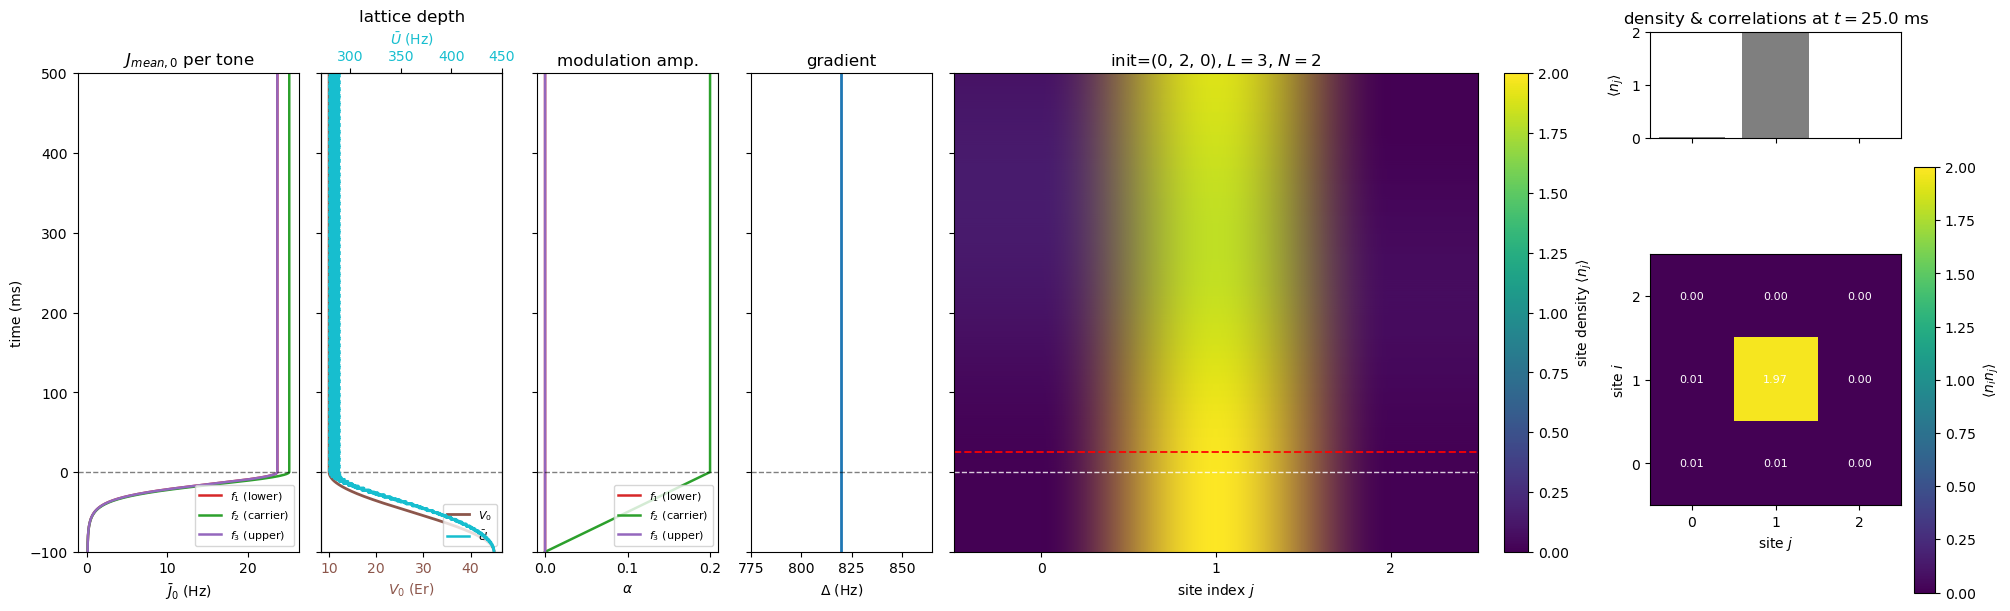

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================
# evolve_grad_V0_floquet
# -------------------------------------------------------------
# Evolve an initial Fock state under a Floquet-driven, tilted
# Bose-Hubbard chain and plot the result.
#
# Physics
# -------
# The lattice depth is modulated by up to three tones,
#     V(t) = V0(t) * (1 + sum_k alpha_k(t) * cos(omega_k t)),
# and the instantaneous tunneling follows the empirical
# depth->tunneling map  J(t) = V_to_J(V(t)).  The on-site
# interaction ALSO follows the depth, U(t) = U_of_V(V(t)), so it
# inherits a few-Hz-level modulation from the drive.  A linear
# tilt (gradient) Delta(t) acts alongside.  The time-dependent
# Hamiltonian is
#     H(t) =  J(t) * H_hop  -  Delta(t) * sum_j j n_j
#             +  (U(t)/2) sum_j n_j(n_j-1).
#
# The full driven Hamiltonian is integrated EXACTLY (no Floquet/
# rotating-wave averaging): solve_ivp propagates the fast-
# oscillating H(t) directly.
#
# Drive frequencies are a lower sideband, the carrier, and an
# upper sideband:
#     freq0_drive_hz = [Delta_fixed - (U - Ueff),
#                       Delta_fixed,
#                       Delta_fixed + (U - Ueff)],
# with optional per-tone AC-Stark detunings added on top.
#
# Each control (lattice depth, modulation amplitude alpha, and
# tilt Delta) is ramped independently between user-set start/end
# times with its own shape (linear / cosine / exponential).
#
# Plots (single row)
# ------------------
#   1. J_mean_0 for each of the three drive tones vs time
#   2. lattice-depth ramp V0(t)
#   3. modulation-amplitude ramp(s) alpha_k(t)
#   4. tilt ramp Delta(t)
#   5. site-density heatmap vs time (correlation time marked)
#   6. 1D site density at t_correlation_plot_ms (above) sitting
#      over the particle-particle correlation matrix <n_i n_j>
#      at that same time (below), sharing the site axis.
# =============================================================


def evolve_grad_V0_floquet(state_init,
                           U_hz,
                           Ueff_hz,
                           V0_range_ER,
                           t_ramp_V0,
                           RAMP_SHAPE_V0,
                           alpha,
                           t_ramp_alpha,
                           RAMP_SHAPE_ALPHA,
                           DETUNING_ON,
                           detuning_vals_hz,
                           Delta_range_hz,
                           Delta_fixed_hz,
                           t_ramp_Delta,
                           RAMP_SHAPE_DELTA,
                           t_correlation_plot_ms,
                           t_evolution_ms):
    """
    Parameters
    ----------
    state_init : list/array of int
        Initial Fock state. Sets L = len(state_init) and N = sum(state_init).
        e.g. [0,2,0] -> N=2, L=3.
    U_hz : float
        On-site interaction (Hz) used in the Hamiltonian.
    Ueff_hz : float
        Effective interaction (Hz) entering the sideband spacing of the drive
        frequencies: the sidebands sit at Delta_fixed +/- (U_hz - Ueff_hz).
    V0_range_ER : [V0_init_ER, V0_final_ER]
        Lattice depth (Er) at the start and end of the depth ramp. The depth
        modulation rides on the INSTANTANEOUS ramped depth V0(t): during the
        ramp it modulates the current depth, afterwards it modulates V0_final.
    t_ramp_V0 : [t_V0_ramp_init_ms, t_V0_ramp_final_ms]
        Start and end times (ms) of the lattice-depth ramp.
    RAMP_SHAPE_V0 : "linear" | "cosine" | "exponential"
        Shape of the lattice-depth ramp.
    alpha : [alpha1, alpha2, alpha3]
        Final depth-modulation amplitudes (relative to V0) for the three drive
        tones freq_drive_hz = [f1, f2, f3].
    t_ramp_alpha : [t_alpha_ramp_init_ms, t_alpha_ramp_final_ms]
        Start and end times (ms) of the alpha ramp (all tones share the timing).
    RAMP_SHAPE_ALPHA : "linear" | "cosine" | "exponential"
        Shape of the alpha ramp.
    DETUNING_ON : [bool, bool, bool]
        Per-tone toggle adding the AC-Stark detuning to each drive frequency.
    detuning_vals_hz : [] or [d1, d2, d3]
        Per-tone detuning override (Hz). If empty, detunings for the enabled
        tones come from the built-in second-order formula. If a 3-list, those
        values are used directly for the enabled tones (still gated by
        DETUNING_ON), bypassing the formula.
    Delta_range_hz : [Delta_init_hz, Delta_final_hz]
        Tilt/gradient magnitude (Hz) at the start and end of its ramp.
    Delta_fixed_hz : float
        Fixed tilt (Hz) used only to set the drive frequencies (independent of
        the ramped Delta that enters the Hamiltonian).
    t_ramp_Delta : [t_Delta_ramp_init_ms, t_Delta_ramp_final_ms]
        Start and end times (ms) of the Delta ramp.
    RAMP_SHAPE_DELTA : "linear" | "cosine" | "exponential"
        Shape of the Delta ramp.
    t_correlation_plot_ms : float
        Time (ms) at which to evaluate the 1D density and <n_i n_j>.
    t_evolution_ms : float
        Total hold-evolution time after t = 0 (ms); sets the end of the trace.
    """

    # =========================================================
    # 1.  Unpack inputs and set up unit conventions
    # =========================================================
    PLOT_SITES  = []                    # site-occupation line cuts off (unused)
    TIME_EVOLVE = t_evolution_ms        # total evolution time after t = 0 (ms)

    state_init = list(state_init)
    L = len(state_init)                 # number of sites
    N = sum(state_init)                 # number of particles

    V0_init_ER, V0_final_ER       = V0_range_ER
    Delta_init_hz, Delta_final_hz = Delta_range_hz
    t_V0_ramp_init_ms,  t_V0_ramp_final_ms    = t_ramp_V0
    t_alpha_ramp_init_ms, t_alpha_ramp_final_ms = t_ramp_alpha
    t_Delta_ramp_init_ms, t_Delta_ramp_final_ms = t_ramp_Delta

    alpha_final = np.asarray(alpha, dtype=float)       # (3,) final tone amplitudes
    DETUNING_ON = np.asarray(DETUNING_ON, dtype=bool)  # (3,) per-tone toggles

    twopi = 2.0 * np.pi

    # ---- empirical lattice-depth -> tunneling map (Er in, Hz out) ----
    def V_to_J(V):
        V = np.asarray(V, dtype=float)
        a = 284.4; b = -0.2922; c = 30.69; d = -0.1304
        return a * np.exp(b * V) + c * np.exp(d * V)

    # ---- empirical lattice-depth -> on-site interaction map (Er in, Hz out) ----
    # Fit form U(V) = a*V^(1/4) + b. Because U follows the lattice depth, the
    # depth modulation makes U(t) weakly time-dependent (few-Hz level).
    def U_of_V(V):
        V = np.asarray(V, dtype=float)
        a = 193.9; b = -60.06
        return a * V**0.25 + b

    # =========================================================
    # 2.  Drive frequencies and AC-Stark detunings
    # =========================================================
    # Sidebands are split from the carrier by (U - Ueff): the carrier sits at
    # the tilt Delta_fixed, the lower/upper sidebands at Delta_fixed -/+ (U-Ueff).
    freq0_drive_hz = np.array([Delta_fixed_hz - (U_hz - Ueff_hz),
                               Delta_fixed_hz,
                               Delta_fixed_hz + (U_hz - Ueff_hz)], dtype=float)

    # Second-order AC-Stark coefficients per tone: [lower, carrier, upper].
    det_coeff = np.array([3.18, 2.30, -0.77], dtype=float)

    def J_mean_0_tone(k, n_sub=10000):
        """Time-averaged J over one period of tone k, evaluated at the final
        depth V0_final_ER with that tone's final modulation amplitude. Used to
        size the (steady-state) AC-Stark detuning for tone k."""
        f_hz = freq0_drive_hz[k]
        om = twopi * f_hz
        T  = 1.0 / f_hz
        t  = np.linspace(0.0, T, n_sub, endpoint=False)
        Vt = V0_final_ER * (1.0 + alpha_final[k] * np.cos(om * t))
        return V_to_J(Vt).mean()

    # Per-tone detuning, applied only where DETUNING_ON[k] is True.
    #   - if detuning_vals_hz is given (non-empty), use those values directly
    #   - otherwise compute from the built-in second-order AC-Stark formula
    detuning_vals_hz = np.asarray(detuning_vals_hz, dtype=float).ravel()
    use_override = detuning_vals_hz.size > 0
    if use_override and detuning_vals_hz.size != 3:
        raise ValueError("detuning_vals_hz must be empty or a list of 3 values.")

    det_hz = np.zeros(3, dtype=float)
    for k in range(3):
        if DETUNING_ON[k]:
            if use_override:
                det_hz[k] = detuning_vals_hz[k]
            else:
                Jm = J_mean_0_tone(k)
                det_hz[k] = det_coeff[k] * Jm**2 / freq0_drive_hz[k]

    freq_drive_hz = freq0_drive_hz + det_hz      # actual drive frequencies (Hz)
    omega_drive   = twopi * freq_drive_hz        # (3,) angular (rad/s)

    # =========================================================
    # 3.  Convert remaining quantities to working units
    # =========================================================
    Delta_init  = twopi * Delta_init_hz          # rad/s
    Delta_final = twopi * Delta_final_hz          # rad/s
    # Note: the interaction is no longer a constant — U(t) = U_of_V(V_of_t(t))
    # is evaluated per timestep (see U_angular_of_t). U_hz still sets the drive
    # sideband spacing below via freq0_drive_hz.

    # ramp start/end times: ms -> s
    t_V0_init_s  = t_V0_ramp_init_ms  * 1e-3
    t_V0_final_s = t_V0_ramp_final_ms * 1e-3
    t_a_init_s   = t_alpha_ramp_init_ms  * 1e-3
    t_a_final_s  = t_alpha_ramp_final_ms * 1e-3
    t_D_init_s   = t_Delta_ramp_init_ms  * 1e-3
    t_D_final_s  = t_Delta_ramp_final_ms * 1e-3
    TIME_EVOLVE_s = TIME_EVOLVE * 1e-3

    # =========================================================
    # 4.  Ramp helper and the three time-dependent controls
    # =========================================================
    def ramp(t, v_init, v_final, t_init, t_final, shape):
        """Shaped interpolation from v_init (t<=t_init) to v_final (t>=t_final)."""
        if t_final <= t_init:                       # degenerate / instantaneous
            return v_final if t >= t_final else v_init
        if t <= t_init:
            return v_init
        if t >= t_final:
            return v_final
        s = (t - t_init) / (t_final - t_init)       # progress in (0, 1)
        if shape == "linear":
            w = s
        elif shape == "cosine":
            w = 0.5 * (1.0 - np.cos(np.pi * s))     # smooth S-curve
        elif shape == "exponential":
            tau = 1.0 / 3.0
            w = (1.0 - np.exp(-s / tau)) / (1.0 - np.exp(-1.0 / tau))
        else:
            raise ValueError("shape must be 'linear', 'cosine', or 'exponential'")
        return v_init + (v_final - v_init) * w

    def V0_of_t(t):
        """Instantaneous (un-modulated) lattice depth (Er)."""
        return ramp(t, V0_init_ER, V0_final_ER, t_V0_init_s, t_V0_final_s, RAMP_SHAPE_V0)

    def alpha_of_t(t):
        """Instantaneous modulation amplitudes (3,) — all tones share one ramp,
        each scaling from 0 to its final alpha_final[k]."""
        w = ramp(t, 0.0, 1.0, t_a_init_s, t_a_final_s, RAMP_SHAPE_ALPHA)
        return alpha_final * w

    def Delta_of_t(t):
        """Instantaneous tilt (rad/s) entering the Hamiltonian."""
        return ramp(t, Delta_init, Delta_final, t_D_init_s, t_D_final_s, RAMP_SHAPE_DELTA)

    # ---- instantaneous modulated depth and tunneling ----
    def V_of_t(t):
        """Modulated lattice depth: V0(t) * (1 + sum_k alpha_k(t) cos(omega_k t))."""
        a_t   = alpha_of_t(t)                              # (3,)
        drive = np.sum(a_t * np.cos(omega_drive * t))      # scalar
        return V0_of_t(t) * (1.0 + drive)

    def J_angular_of_t(t):
        """Instantaneous tunneling (rad/s) from the depth->J map."""
        return twopi * V_to_J(V_of_t(t))

    def U_angular_of_t(t):
        """Instantaneous on-site interaction (rad/s) from the depth->U map,
        evaluated at the full MODULATED depth V_of_t(t) so the drive imprints
        its few-Hz-level modulation onto U(t)."""
        return twopi * U_of_V(V_of_t(t))

    # =========================================================
    # 5.  Fixed-N Fock basis
    # =========================================================
    def generate_basis(L, N):
        return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
                if sum(occ) == N]
    basis = generate_basis(L, N)
    index = {s: i for i, s in enumerate(basis)}
    dim   = len(basis)

    # ---- console summary of the configured run ----
    print("L = %d, N = %d, dim = %d" % (L, N, dim))
    print("U = %.1f Hz, Ueff = %.1f Hz" % (U_hz, Ueff_hz))
    print("freq0_drive_hz = [%.2f, %.2f, %.2f] Hz (lower, carrier, upper)"
          % tuple(freq0_drive_hz))
    print("detuning_on    = [%s, %s, %s] (%s) -> det_hz = [%.3f, %.3f, %.3f] Hz"
          % (DETUNING_ON[0], DETUNING_ON[1], DETUNING_ON[2],
             "override" if use_override else "formula",
             det_hz[0], det_hz[1], det_hz[2]))
    print("freq_drive_hz  = [%.3f, %.3f, %.3f] Hz" % tuple(freq_drive_hz))
    print("V0 ramp:    %.3f -> %.3f Er, %.1f -> %.1f ms (%s)"
          % (V0_init_ER, V0_final_ER, t_V0_ramp_init_ms, t_V0_ramp_final_ms,
             RAMP_SHAPE_V0))
    print("alpha ramp: 0 -> %s, %.1f -> %.1f ms (%s)"
          % (np.array2string(alpha_final, precision=3),
             t_alpha_ramp_init_ms, t_alpha_ramp_final_ms, RAMP_SHAPE_ALPHA))
    print("Delta ramp: %.3f -> %.3f Hz, %.1f -> %.1f ms (%s)"
          % (Delta_init_hz, Delta_final_hz, t_Delta_ramp_init_ms,
             t_Delta_ramp_final_ms, RAMP_SHAPE_DELTA))

    # =========================================================
    # 6.  Hamiltonian pieces (unit prefactors; couplings applied in rhs)
    # =========================================================
    def build_hop_unit():
        """Nearest-neighbour hopping with unit amplitude, open chain."""
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            for j in range(L - 1):
                if n[j] > 0:                       # hop j -> j+1
                    new = n.copy(); amp = np.sqrt(n[j]) * np.sqrt(n[j+1] + 1)
                    new[j] -= 1; new[j+1] += 1
                    H[index[tuple(new)], a] += -amp
                if n[j+1] > 0:                     # hop j+1 -> j
                    new = n.copy(); amp = np.sqrt(n[j+1]) * np.sqrt(n[j] + 1)
                    new[j+1] -= 1; new[j] += 1
                    H[index[tuple(new)], a] += -amp
        return H

    def build_tilt_unit():
        """Diagonal tilt operator -sum_j j n_j (multiplied by Delta(t))."""
        H = np.zeros((dim, dim), dtype=complex)
        sites = np.arange(L)
        for a, state in enumerate(basis):
            n = np.array(state)
            H[a, a] = -np.sum(sites * n)
        return H

    def build_int_unit():
        """Unit on-site interaction operator (1/2) sum_j n_j(n_j-1).
        The time-dependent U(t) multiplies this in the RHS, so the interaction
        tracks the (modulated) lattice depth rather than being static."""
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            H[a, a] = 0.5 * np.sum(n * (n - 1))
        return H

    H_hop_unit  = build_hop_unit()
    H_tilt_unit = build_tilt_unit()
    H_int_unit  = build_int_unit()

    # ---- site-density operators n_j (diagonal in the Fock basis) ----
    n_ops = []
    for site in range(L):
        op = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            op[a, a] = state[site]
        n_ops.append(op)

    # ---- initial state vector ----
    psi0 = np.zeros(dim, dtype=complex)
    psi0[index[tuple(state_init)]] = 1.0
    print("initial state =", tuple(state_init))

    # =========================================================
    # 7.  Exact time evolution of the fully driven system
    # =========================================================
    def rhs(t, psi):
        H = (J_angular_of_t(t) * H_hop_unit
             + Delta_of_t(t)   * H_tilt_unit
             + U_angular_of_t(t) * H_int_unit)
        return -1j * H.dot(psi)

    # integrate from the earliest ramp start to the end of the hold
    t_start = min(0.0, t_V0_init_s, t_a_init_s, t_D_init_s)
    t_end   = TIME_EVOLVE_s
    n_times = 1200
    times   = np.linspace(t_start, t_end, n_times)

    # resolve the fast drive timescale: cap the step at ~1/30 of the shortest
    # drive period so the integrator never steps over an oscillation
    pos_f = freq_drive_hz[freq_drive_hz > 0]
    fastest_f = np.max(pos_f) if pos_f.size else None
    max_step  = (1.0 / fastest_f) / 30.0 if fastest_f else np.inf

    sol = solve_ivp(rhs, (t_start, t_end), psi0, t_eval=times,
                    rtol=1e-9, atol=1e-9, method="DOP853", max_step=max_step)
    psis = sol.y.T
    print("final norm =", np.linalg.norm(psis[-1]))

    # =========================================================
    # 8.  Observables: density vs time and the snapshot correlation matrix
    # =========================================================
    # site density <n_site>(t) on the solution grid
    density = np.zeros((len(times), L))
    for ti, p in enumerate(psis):
        for site in range(L):
            density[ti, site] = np.vdot(p, n_ops[site].dot(p)).real

    # precompute occupation vectors for each basis state (for <n_i n_j>)
    n_basis = np.array([list(s) for s in basis], dtype=float)   # (dim, L)

    def state_at_time(t_query_s):
        """Wavefunction at an arbitrary time via linear interpolation on the
        solution grid (renormalized)."""
        if t_query_s <= times[0]:
            return psis[0]
        if t_query_s >= times[-1]:
            return psis[-1]
        k = np.searchsorted(times, t_query_s) - 1
        k = min(max(k, 0), len(times) - 2)
        frac = (t_query_s - times[k]) / (times[k+1] - times[k])
        psi = (1.0 - frac) * psis[k] + frac * psis[k+1]
        nrm = np.linalg.norm(psi)
        return psi / nrm if nrm > 0 else psi

    # state at the requested correlation time -> density line and G_ij
    t_corr_s   = t_correlation_plot_ms * 1e-3
    psi_corr   = state_at_time(t_corr_s)
    prob_corr  = np.abs(psi_corr)**2
    density_corr = np.array([np.vdot(psi_corr, n_ops[s].dot(psi_corr)).real
                             for s in range(L)])     # 1D density at t_corr
    G_corr = np.zeros((L, L), dtype=float)           # <n_i n_j> at t_corr
    for k in range(dim):
        G_corr += prob_corr[k] * np.outer(n_basis[k], n_basis[k])

    Gamma_corr = np.zeros((L, L), dtype=float)
    for k in range(dim):
        n = n_basis[k]
        Gamma_corr += prob_corr[k] * np.outer(n, n)
        Gamma_corr[np.diag_indices(L)] -= prob_corr[k] * n

    # =========================================================
    # 9.  Profiles for the ramp side-panels
    # =========================================================
    times_ms = 1000.0 * times

    def J_mean_0_inst(k, t_center, n_sub=400):
        """Time-averaged J over one period of tone k, using the instantaneous
        V0(t) and alpha_k(t) at t_center (so it tracks the ramps)."""
        f_hz = freq_drive_hz[k]
        if f_hz <= 0:
            return V_to_J(V0_of_t(t_center))
        om  = twopi * f_hz
        T   = 1.0 / f_hz
        tt  = t_center + np.linspace(0.0, T, n_sub, endpoint=False)
        a_k = alpha_of_t(t_center)[k]
        V0c = V0_of_t(t_center)
        Vt  = V0c * (1.0 + a_k * np.cos(om * tt))
        return V_to_J(Vt).mean()

    Jmean_profiles = np.zeros((len(times), 3))
    for ti, tc in enumerate(times):
        for k in range(3):
            Jmean_profiles[ti, k] = J_mean_0_inst(k, tc)

    V0_profile_ER    = np.array([V0_of_t(t) for t in times])
    alpha_profiles   = np.array([alpha_of_t(t) for t in times])      # (ntimes, 3)
    Delta_profile_hz = np.array([Delta_of_t(t) for t in times]) / twopi

    # cycle-averaged U(t) (Hz): average U_of_V over one period of the fastest
    # active tone, so it shows the slow drift/shift rather than the fast wiggle.
    def U_mean_inst(t_center, n_sub=400):
        pos = freq_drive_hz[freq_drive_hz > 0]
        if pos.size == 0 or np.allclose(alpha_of_t(t_center), 0.0):
            return U_of_V(V_of_t(t_center))
        f_hz = np.max(pos)
        T    = 1.0 / f_hz
        tt   = t_center + np.linspace(0.0, T, n_sub, endpoint=False)
        Vt   = np.array([V_of_t(tau) for tau in tt])
        return U_of_V(Vt).mean()

    U_profile_hz = np.array([U_mean_inst(t) for t in times])

    # =========================================================
    # 10.  Figure: ramp panels | density heatmap | density+correlation
    # =========================================================
    fig = plt.figure(figsize=(20, 6), constrained_layout=True)
    gs = fig.add_gridspec(1, 6,
                          width_ratios=[1.1, 0.9, 0.9, 0.9, 2.6, 2.0],
                          wspace=0.05)
    axJ = fig.add_subplot(gs[0, 0])               # J_mean_0 per tone
    axV = fig.add_subplot(gs[0, 1], sharey=axJ)   # lattice depth
    axA = fig.add_subplot(gs[0, 2], sharey=axJ)   # modulation amplitude
    axD = fig.add_subplot(gs[0, 3], sharey=axJ)   # tilt Delta
    axR = fig.add_subplot(gs[0, 4], sharey=axJ)   # density heatmap

    # split the last column into a small density strip over the corr. matrix
    gs_corr = gs[0, 5].subgridspec(2, 1, height_ratios=[1, 4], hspace=0.05)
    axDen = fig.add_subplot(gs_corr[0, 0])        # 1D density at t_corr
    axC   = fig.add_subplot(gs_corr[1, 0], sharex=axDen)  # <n_i n_j> at t_corr

    tone_colors = ["tab:red", "tab:green", "tab:purple"]
    tone_labels = [r"$f_1$ (lower)", r"$f_2$ (carrier)", r"$f_3$ (upper)"]

    # --- panel 1: J_mean_0 for each tone ---
    for k in range(3):
        axJ.plot(Jmean_profiles[:, k], times_ms, color=tone_colors[k],
                 lw=1.8, label=tone_labels[k])
    axJ.set_xlabel(r"$\bar{J}_0$ (Hz)")
    axJ.set_ylabel("time (ms)")
    axJ.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axJ.set_title(r"$J_{mean,0}$ per tone")
    axJ.legend(fontsize=8, loc="lower right")
    axJ.margins(y=0)

    # --- panel 2: lattice depth V0(t), with cycle-averaged U(t) overlaid ---
    lnV, = axV.plot(V0_profile_ER, times_ms, color="tab:brown", lw=2.0, label=r"$V_0$")
    axV.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axV.set_xlabel(r"$V_0$ (Er)", color="tab:brown")
    axV.tick_params(axis="x", labelcolor="tab:brown")
    axV.set_title("lattice depth")
    axV.tick_params(labelleft=False)

    axVt = axV.twiny()                              # U(t) on its own x-scale
    lnU, = axVt.plot(U_profile_hz, times_ms, color="tab:cyan", lw=1.8,
                     ls="-", label=r"$\bar{U}$")
    axVt.set_xlabel(r"$\bar{U}$ (Hz)", color="tab:cyan")
    axVt.tick_params(axis="x", labelcolor="tab:cyan")
    axV.legend(handles=[lnV, lnU], loc="lower right", fontsize=8)

    # --- panel 3: modulation amplitude alpha_k(t) ---
    for k in range(3):
        axA.plot(alpha_profiles[:, k], times_ms, color=tone_colors[k],
                 lw=1.8, label=tone_labels[k])
    axA.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axA.set_xlabel(r"$\alpha$")
    axA.set_title("modulation amp.")
    axA.tick_params(labelleft=False)
    axA.legend(fontsize=8, loc="lower right")

    # --- panel 4: tilt Delta(t) ---
    axD.plot(Delta_profile_hz, times_ms, color="tab:blue", lw=2.0)
    axD.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axD.set_xlabel(r"$\Delta$ (Hz)")
    axD.set_title("gradient")
    axD.tick_params(labelleft=False)

    # --- panel 5: site-density heatmap vs time ---
    im = axR.imshow(density, aspect="auto", origin="lower",
                    extent=[-0.5, L - 0.5, times_ms[0], times_ms[-1]],
                    cmap="viridis", vmin=0.0, vmax=N)
    axR.axhline(0.0, color="w", lw=1.0, ls="--", alpha=0.8)          # t = 0
    axR.axhline(t_correlation_plot_ms, color="r", lw=1.4, ls="--", alpha=0.9)
    axR.set_xlabel("site index $j$")
    axR.set_xticks(range(L))
    axR.set_title(r"init=%s, $L=%d$, $N=%d$" % (tuple(state_init), L, N))
    axR.tick_params(labelleft=False)
    fig.colorbar(im, ax=axR, label=r"site density $\langle n_j \rangle$")

    # --- panel 6a: 1D site density at the correlation time ---
    axDen.bar(range(L), density_corr, color="tab:gray", width=0.8)
    axDen.set_ylim(0.0, N)
    axDen.set_ylabel(r"$\langle n_j\rangle$")
    axDen.set_title(r"density & correlations at $t=%.1f$ ms" % t_correlation_plot_ms)
    axDen.tick_params(labelbottom=False)          # share site axis with matrix
    axDen.margins(x=0)

    # --- panel 6b: particle-particle correlation matrix at the same time ---
    imC = axC.imshow(Gamma_corr, origin="lower", cmap="viridis",
                     vmin=0.0, vmax=N*(N-1),
                     extent=[-0.5, L - 0.5, -0.5, L - 0.5])
    axC.set_xticks(range(L)); axC.set_yticks(range(L))
    axC.set_xlabel("site $j$"); axC.set_ylabel("site $i$")
    fig.colorbar(imC, ax=axC, label=r"$\langle n_i n_j \rangle$")
    if L <= 8:                                     # annotate cells when readable
        for i in range(L):
            for j in range(L):
                axC.text(j, i, "%.2f" % Gamma_corr[i, j], ha="center", va="center",
                         color="w", fontsize=8)

    plt.savefig("evolve_grad_V0_floquet.png", dpi=120)
    plt.show()


# =============================================================
# Example call
# =============================================================
if __name__ == "__main__":
    evolve_grad_V0_floquet(
        state_init            = [0, 2, 0],
        U_hz                  = 280.0,
        Ueff_hz               = 0.0,
        V0_range_ER           = [45.0, 10.0],
        t_ramp_V0             = [-100.0, 0.0],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.0, 0.2, 0.0],
        t_ramp_alpha          = [-100.0, 0.0],
        RAMP_SHAPE_ALPHA      = "linear",
        DETUNING_ON           = [False, True, False],
        detuning_vals_hz      = [],
        Delta_range_hz        = [820.0, 820.0],
        Delta_fixed_hz        = 820.0,
        t_ramp_Delta          = [-100.0, 0.0],
        RAMP_SHAPE_DELTA      = "linear",
        t_correlation_plot_ms = 25.0,
        t_evolution_ms        = 500,
    )

L = 2, N = 1, dim = 2
U = 261.0 Hz, Ueff = 0.0 Hz
freq0_drive_hz = [559.00, 820.00, 1081.00] Hz (lower, carrier, upper)
detuning_on    = [True, True, True] (formula) -> det_hz = [10.677, 5.674, -1.337] Hz
freq_drive_hz  = [569.677, 825.674, 1079.663] Hz
V0 ramp:    45.000 -> 7.500 Er, -10.0 -> 0.0 ms (cosine)
alpha ramp: 0 -> [0.  0.2 0. ], -0.0 -> 0.0 ms (cosine)
Delta ramp: 820.000 -> 820.000 Hz, -0.0 -> 0.0 ms (cosine)
initial state = (0, 1)
final norm = 0.9999999999995407


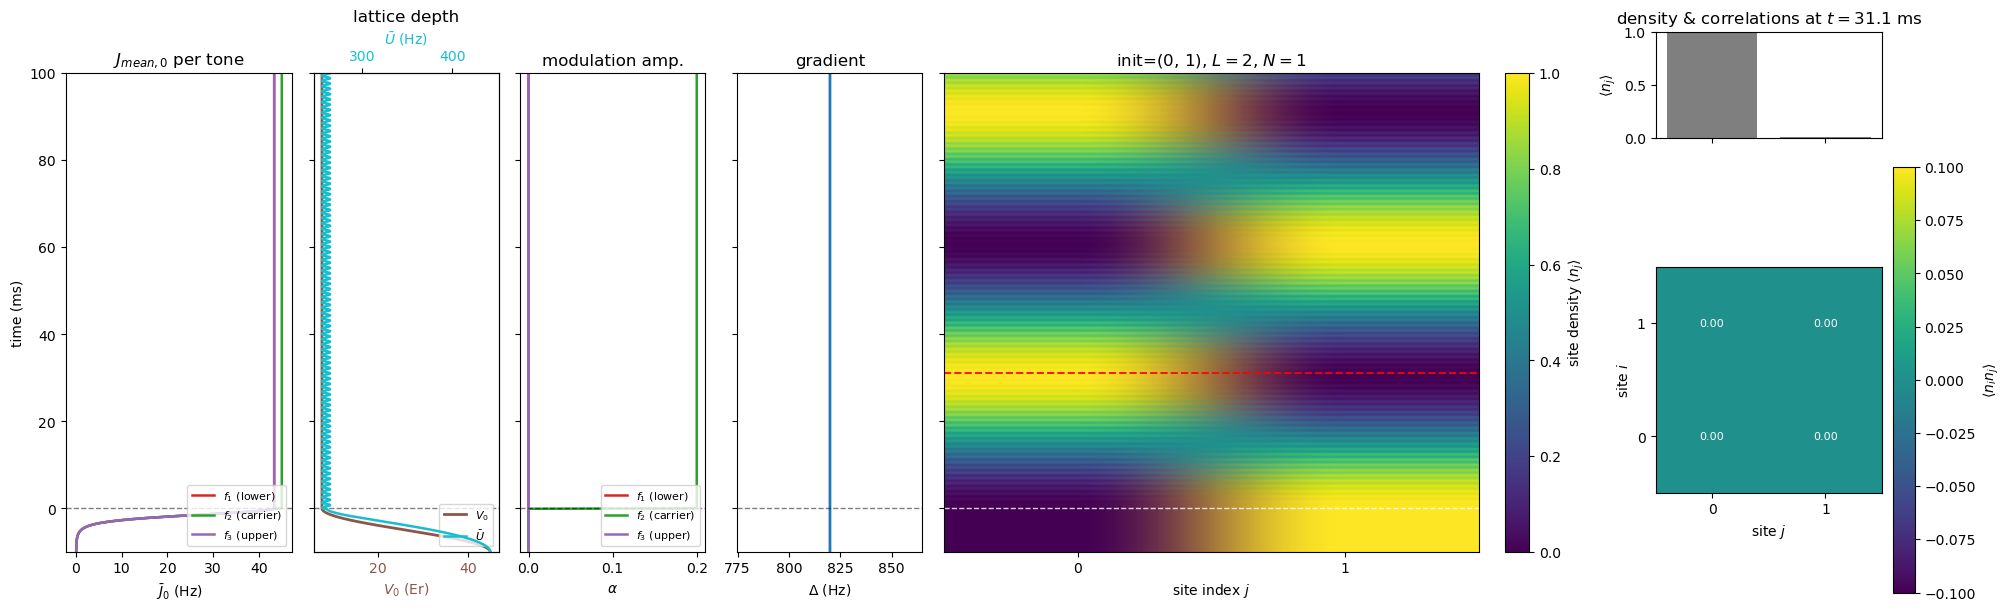

In [9]:
# rabi oscillations, N=1, single-tone
evolve_grad_V0_floquet(
        state_init            = [0, 1],
        U_hz                  = 261.0,
        Ueff_hz               = 0.0,
        V0_range_ER           = [45.0, 7.5],
        t_ramp_V0             = [-10.0, 0.0],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.0, 0.2, 0.0],
        t_ramp_alpha          = [-0.0, 0.0],
        RAMP_SHAPE_ALPHA      = "cosine",
        DETUNING_ON           = [True, True, True],
        detuning_vals_hz      = [],
        Delta_range_hz        = [820.0, 820.0],
        Delta_fixed_hz        = 820.0,
        t_ramp_Delta          = [-0.0, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 22.0 * np.sqrt(2),
        t_evolution_ms        = 100,
    )

L = 2, N = 2, dim = 3
U = 261.0 Hz, Ueff = 0.0 Hz
freq0_drive_hz = [559.00, 820.00, 1081.00] Hz (lower, carrier, upper)
detuning_on    = [True, True, True] (formula) -> det_hz = [11.509, 5.264, -1.337] Hz
freq_drive_hz  = [570.509, 825.264, 1079.663] Hz
V0 ramp:    45.000 -> 7.500 Er, -10.0 -> 0.0 ms (cosine)
alpha ramp: 0 -> [0.2 0.  0. ], -0.0 -> 0.0 ms (cosine)
Delta ramp: 820.000 -> 820.000 Hz, -0.0 -> 0.0 ms (cosine)
initial state = (1, 1)
final norm = 0.9999999999283635


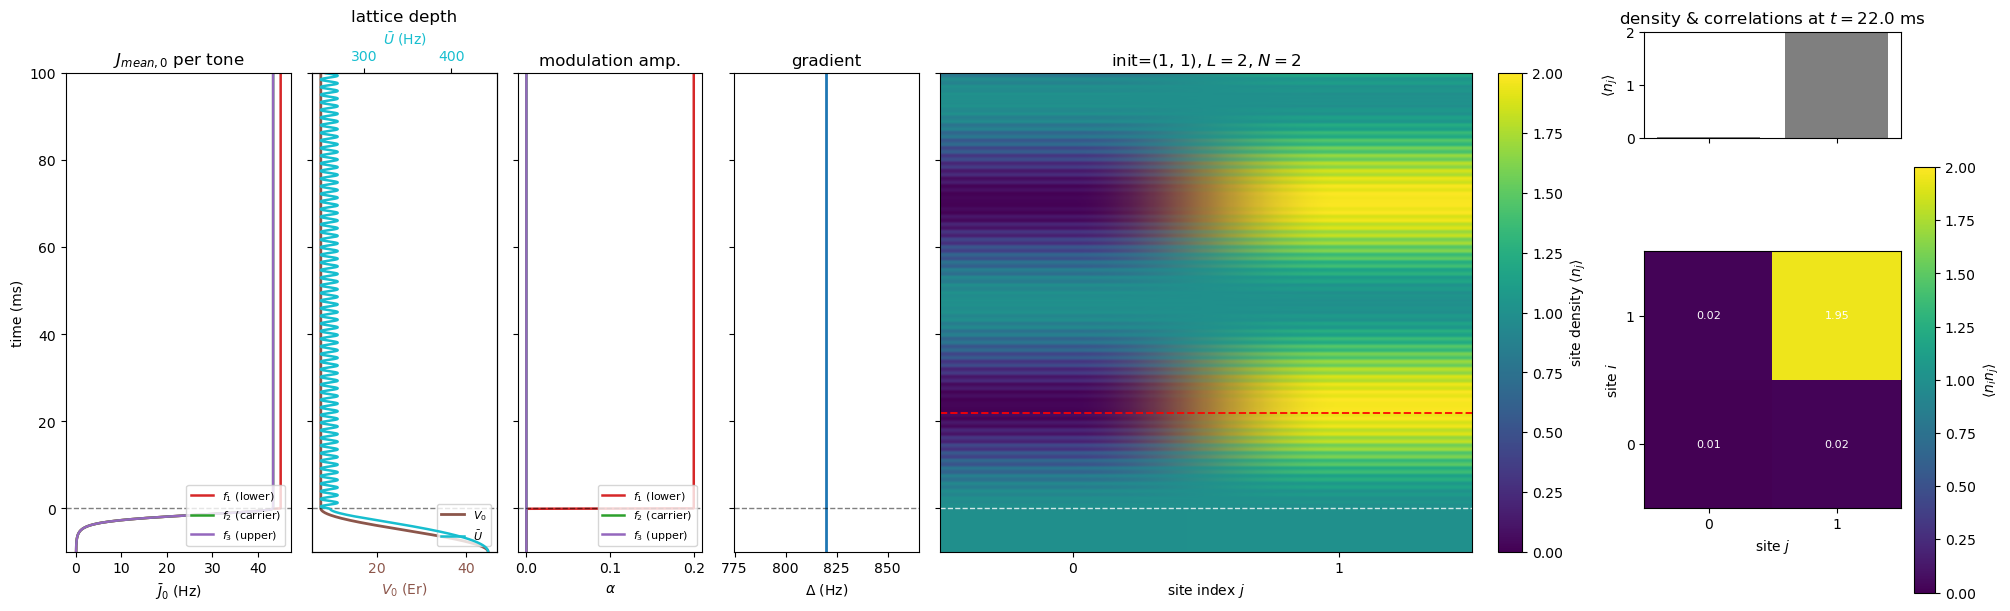

In [11]:
# rabi oscillations, N=2, L=2, single tone
evolve_grad_V0_floquet(
        state_init            = [1, 1],
        U_hz                  = 261.0,
        Ueff_hz               = 0.0,
        V0_range_ER           = [45.0, 7.5],
        t_ramp_V0             = [-10.0, 0.0],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.2, 0.0, 0.0],
        t_ramp_alpha          = [-0.0, 0.0],
        RAMP_SHAPE_ALPHA      = "cosine",
        DETUNING_ON           = [True, True, True],
        detuning_vals_hz      = [],
        Delta_range_hz        = [820.0, 820.0],
        Delta_fixed_hz        = 820.0,
        t_ramp_Delta          = [-0.0, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 22.0,
        t_evolution_ms        = 100,
    )

L = 3, N = 2, dim = 6
U = 261.0 Hz, Ueff = 0.0 Hz
freq0_drive_hz = [559.00, 820.00, 1081.00] Hz (lower, carrier, upper)
detuning_on    = [True, True, True] (formula) -> det_hz = [11.509, 5.264, -1.337] Hz
freq_drive_hz  = [570.509, 825.264, 1079.663] Hz
V0 ramp:    45.000 -> 7.500 Er, -10.0 -> 0.0 ms (cosine)
alpha ramp: 0 -> [0.2 0.  0. ], -0.0 -> 0.0 ms (cosine)
Delta ramp: 820.000 -> 820.000 Hz, -0.0 -> 0.0 ms (cosine)
initial state = (1, 1, 0)
final norm = 0.9999999999107433


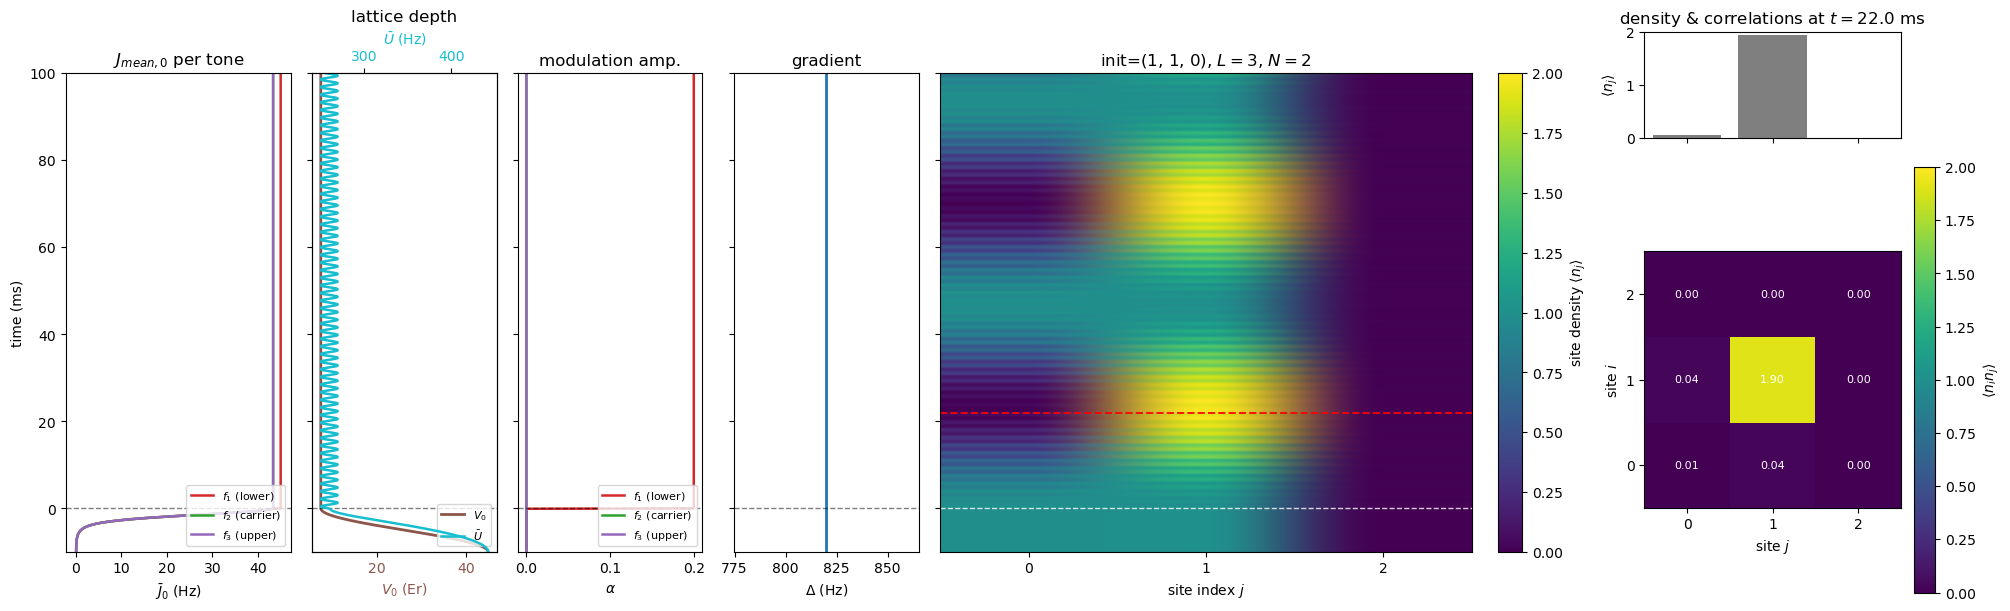

In [13]:
# rabi oscillations, N=2, L=3, single tone
evolve_grad_V0_floquet(
        state_init            = [1, 1, 0],
        U_hz                  = 261.0,
        Ueff_hz               = 0.0,
        V0_range_ER           = [45.0, 7.5],
        t_ramp_V0             = [-10.0, 0.0],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.2, 0.0, 0.0],
        t_ramp_alpha          = [-0.0, 0.0],
        RAMP_SHAPE_ALPHA      = "cosine",
        DETUNING_ON           = [True, True, True],
        detuning_vals_hz      = [],
        Delta_range_hz        = [820.0, 820.0],
        Delta_fixed_hz        = 820.0,
        t_ramp_Delta          = [-0.0, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 22.0,
        t_evolution_ms        = 100,
    )

L = 2, N = 1, dim = 2
U = 261.0 Hz, Ueff = 0.0 Hz
freq0_drive_hz = [534.00, 795.00, 1056.00] Hz (lower, carrier, upper)
detuning_on    = [True, True, True] (formula) -> det_hz = [25.091, 12.189, -3.072] Hz
freq_drive_hz  = [559.091, 807.189, 1052.928] Hz
V0 ramp:    45.000 -> 6.000 Er, -60.0 -> -50.0 ms (cosine)
alpha ramp: 0 -> [0.2 0.2 0.2], -50.0 -> -0.0 ms (cosine)
Delta ramp: 795.000 -> 795.000 Hz, -0.0 -> 0.0 ms (cosine)
initial state = (1, 0)
final norm = 0.9999999999994201


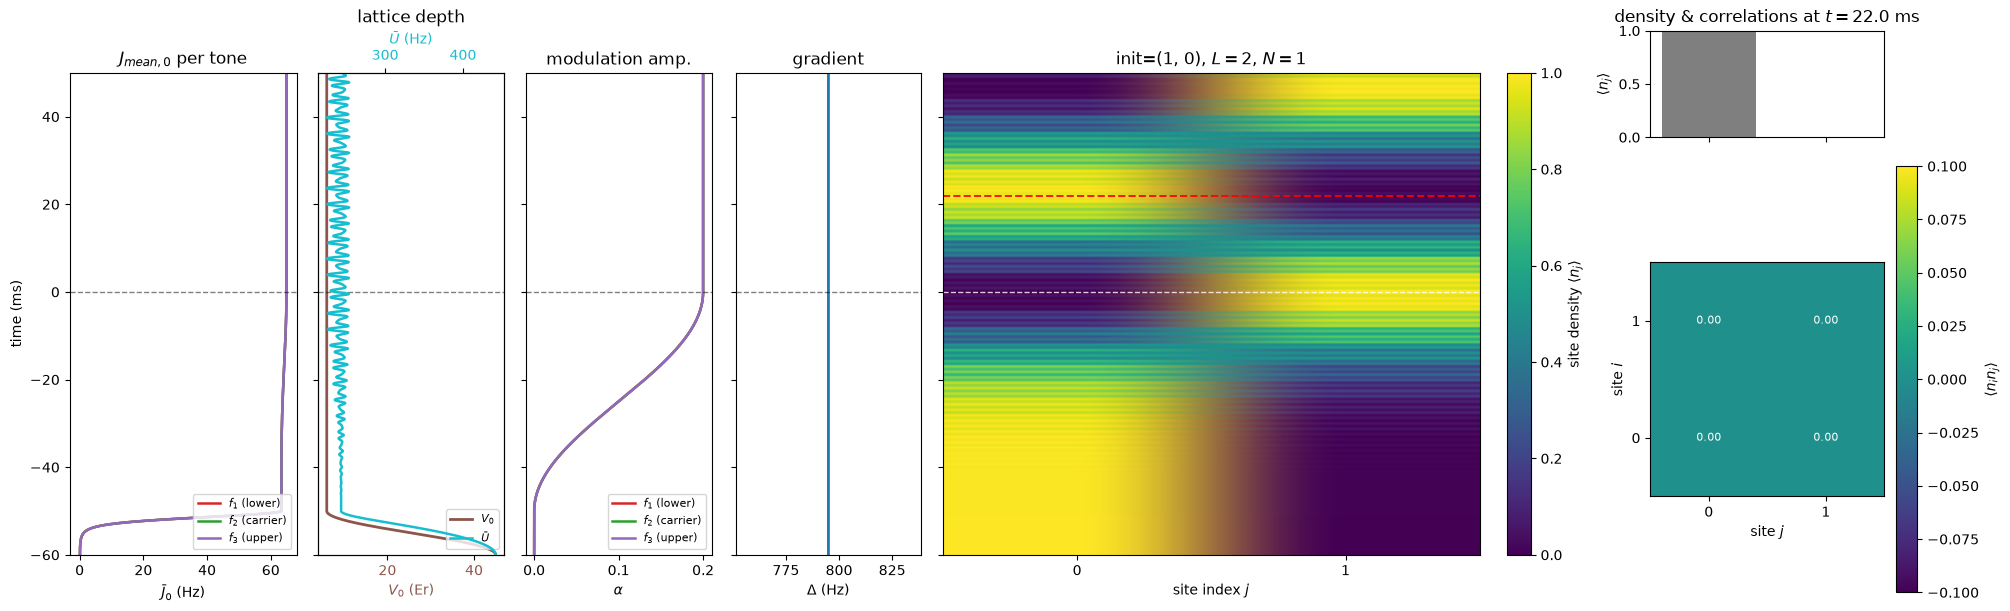

In [431]:
# ----------------------------
# Single particle state
# ----------------------------
lattice_ramp_dur = 10.0
lattice_mod_ramp_dur = 50.0
grad_ramp_dur = 0.0
Jeff_hz = 10.4
Delta_hz = 795.0

evolve_grad_V0_floquet(
        state_init            = [1, 0],
        U_hz                  = 261.0,
        Ueff_hz               = 0.0,
        V0_range_ER           = [45.0, 6],
        t_ramp_V0             = [-lattice_ramp_dur-lattice_mod_ramp_dur-grad_ramp_dur, -lattice_mod_ramp_dur-grad_ramp_dur],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.2, 0.2, 0.2],
        t_ramp_alpha          = [-lattice_mod_ramp_dur-grad_ramp_dur, -grad_ramp_dur],
        RAMP_SHAPE_ALPHA      = "cosine",
        DETUNING_ON           = [True, True, True],
        detuning_vals_hz      = [],
        Delta_range_hz        = [Delta_hz, Delta_hz],
        Delta_fixed_hz        = Delta_hz,
        t_ramp_Delta          = [-0.0, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 22.0,
        t_evolution_ms        = 50,
    )

L = 5, N = 2, dim = 15
U = 231.0 Hz, Ueff = 16.6 Hz
freq0_drive_hz = [580.64, 795.00, 1009.36] Hz (lower, carrier, upper)
detuning_on    = [True, True, True] (override) -> det_hz = [0.000, 0.000, 0.000] Hz
freq_drive_hz  = [580.640, 795.000, 1009.360] Hz
V0 ramp:    45.000 -> 6.000 Er, -360.0 -> -350.0 ms (cosine)
alpha ramp: 0 -> [0.2 0.2 0.2], -350.0 -> -300.0 ms (cosine)
Delta ramp: 839.720 -> 795.000 Hz, -300.0 -> 0.0 ms (cosine)
initial state = (0, 0, 0, 0, 2)
final norm = 0.9999987975253942


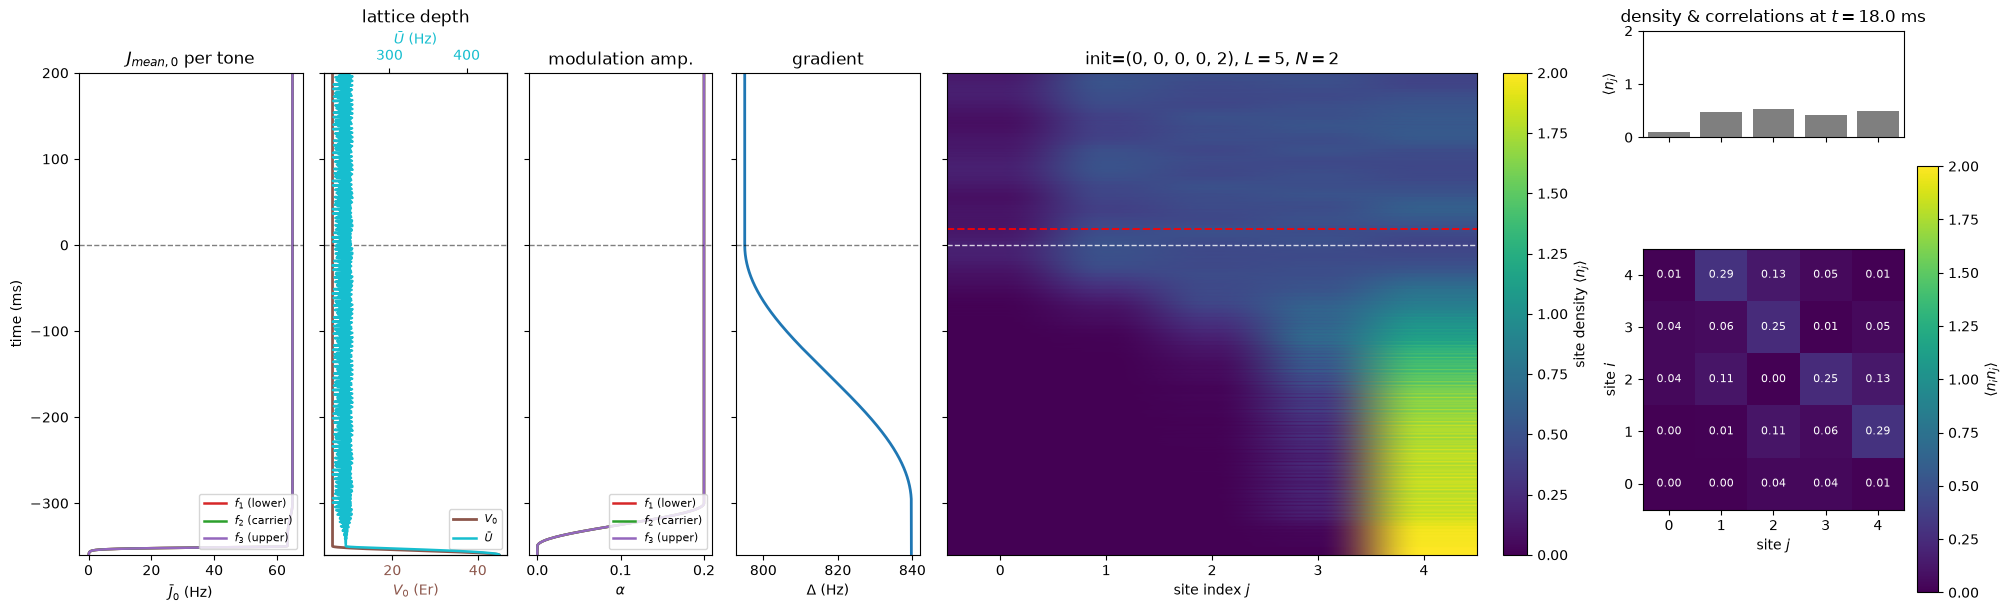

In [434]:
# ----------------------------
# Ground state
# ----------------------------
lattice_ramp_dur = 10.0
lattice_mod_ramp_dur = 50.0
grad_ramp_dur = 300.0
Jeff_hz = 10.4
Delta_hz = 795.0

evolve_grad_V0_floquet(
        state_init            = [0,0,0,0,2],
        U_hz                  = 231.0,
        Ueff_hz               = 1.6 * Jeff_hz,
        V0_range_ER           = [45.0, 6.0],
        t_ramp_V0             = [-lattice_ramp_dur - lattice_mod_ramp_dur - grad_ramp_dur, -lattice_mod_ramp_dur - grad_ramp_dur],
        RAMP_SHAPE_V0         = "cosine",
        alpha                 = [0.2, 0.2, 0.2],
        t_ramp_alpha          = [-lattice_mod_ramp_dur-grad_ramp_dur, -grad_ramp_dur],
        RAMP_SHAPE_ALPHA      = "cosine",
        DETUNING_ON           = [True, True, True],
        detuning_vals_hz      = [0,0,0], #[18.5, 0.0, 0.0],
        # DETUNING_ON           = [False, False, False],
        Delta_range_hz        = [Delta_hz+4.3*Jeff_hz, Delta_hz],
        Delta_fixed_hz        = Delta_hz,
        t_ramp_Delta          = [-grad_ramp_dur, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 18.0,
        t_evolution_ms        = 200,
    )